# Titanic — Baseline Model (Task 3)

**Input:** `data/titanic_clean.csv` — the cleaned output of Task 1, explored in Task 2 (891 rows, 0 missing values).
**Goal:** build a baseline classification model for `Survived`, evaluate it with suitable metrics, and discuss its limitations honestly rather than overselling it.

**Approach:**
1. A **naive baseline** (always predict the majority class) to set a floor.
2. A **Logistic Regression baseline model** — simple, fast, and interpretable, the standard first model for a binary classification problem like this.
3. Evaluation with accuracy, precision, recall, F1, ROC-AUC, a confusion matrix, and 5-fold cross-validation (a single train/test split can be lucky or unlucky).
4. Inspection of which features the model actually relies on.
5. An honest discussion of limitations.


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
import os, warnings
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.titleweight": "bold"})
FIG = "../reports/figures"
os.makedirs(FIG, exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(f"{FIG}/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

df = pd.read_csv("../data/titanic_clean.csv")
print(df.shape)
df.head()

(891, 14)


,PassengerId,Survived,Pclass,Title,Sex,Age,AgeWasMissing,SibSp,Parch,FamilySize,IsAlone,Fare,Deck,Embarked
0,1,0,3,Mr,male,22.0,False,1,0,2,False,7.2500,Unknown,S
1,2,1,1,Mrs,female,38.0,False,1,0,2,False,71.2833,C,C
2,3,1,3,Miss,female,26.0,False,0,0,1,True,7.9250,Unknown,S
3,4,1,1,Mrs,female,35.0,False,1,0,2,False,53.1000,C,S
4,5,0,3,Mr,male,35.0,False,0,0,1,True,8.0500,Unknown,S


## 1. Features and target

`Survived` is the target. Features used:
- **Numeric:** `Age`, `Fare`, `FamilySize`, `SibSp`, `Parch`
- **Categorical:** `Pclass`, `Sex`, `Embarked`, `Title`, `Deck`, `IsAlone`, `AgeWasMissing`

`PassengerId` is dropped (it's just a row identifier). `Name` and `Ticket` were already dropped in Task 1.


In [2]:
target = "Survived"
num_feats = ["Age", "Fare", "FamilySize", "SibSp", "Parch"]
cat_feats = ["Pclass", "Sex", "Embarked", "Title", "Deck", "IsAlone", "AgeWasMissing"]

X = df[num_feats + cat_feats]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Survival rate -> train: {y_train.mean():.3f} | test: {y_test.mean():.3f} (stratified split keeps these close)")

Train: 712 rows | Test: 179 rows
Survival rate -> train: 0.383 | test: 0.385 (stratified split keeps these close)


## 2. Preprocessing pipeline

Numeric features are standardized (helpful for logistic regression); categorical features are one-hot encoded. Wrapping this in a `ColumnTransformer` + `Pipeline` means the same transform is fit on train and cleanly re-applied to test, with no leakage.

In [3]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_feats),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cat_feats),
])

## 3. Naive baseline (floor)

Before trusting any model, check what a trivial rule scores. This model always predicts the majority class (`Survived = 0`).


In [4]:
dummy = Pipeline([("pre", preprocess), ("clf", DummyClassifier(strategy="most_frequent"))])
dummy.fit(X_train, y_train)
dummy_acc = accuracy_score(y_test, dummy.predict(X_test))
print(f"Naive baseline (always predict 'did not survive') accuracy: {dummy_acc:.3f}")
print("Any real model needs to clear this bar by a meaningful margin to be worth using.")

Naive baseline (always predict 'did not survive') accuracy: 0.615
Any real model needs to clear this bar by a meaningful margin to be worth using.


## 4. Baseline model: Logistic Regression

Logistic Regression is the standard baseline for binary classification: fast to train, easy to interpret via coefficients, and a fair benchmark before trying more complex models (Random Forest, Gradient Boosting, etc.).

In [5]:
logreg = Pipeline([("pre", preprocess), ("clf", LogisticRegression(max_iter=1000, random_state=42))])
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}  (of predicted survivors, how many actually survived)")
print(f"Recall:    {rec:.3f}  (of actual survivors, how many the model caught)")
print(f"F1:        {f1:.3f}")
print(f"ROC-AUC:   {auc:.3f}")
print(f"\nImprovement over naive baseline: +{acc - dummy_acc:.3f} accuracy")

Accuracy:  0.849
Precision: 0.818  (of predicted survivors, how many actually survived)
Recall:    0.783  (of actual survivors, how many the model caught)
F1:        0.800
ROC-AUC:   0.872

Improvement over naive baseline: +0.235 accuracy


## 5. Confusion matrix and ROC curve

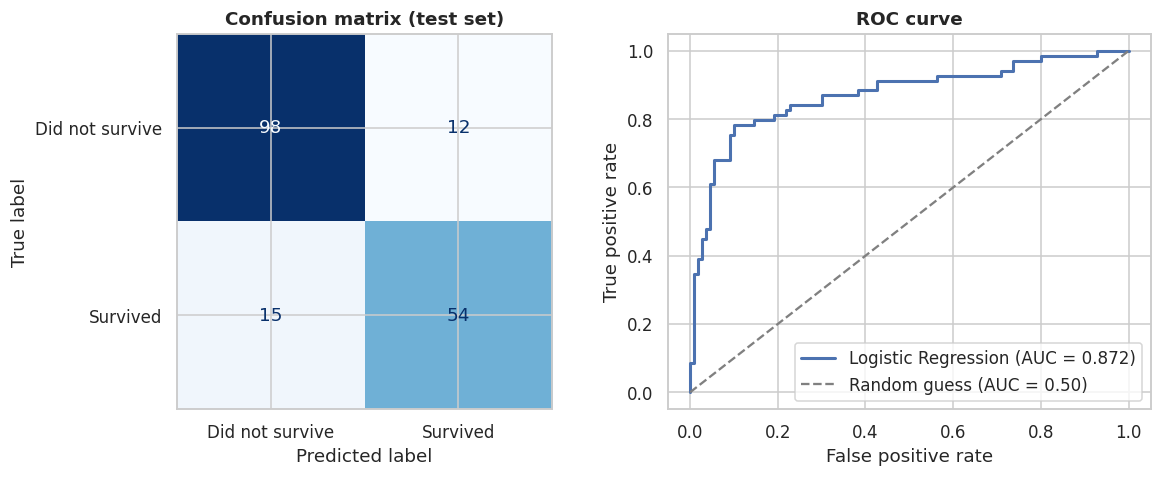

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Did not survive", "Survived"]).plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title("Confusion matrix (test set)")

fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[1].plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})", linewidth=2)
ax[1].plot([0, 1], [0, 1], "--", color="grey", label="Random guess (AUC = 0.50)")
ax[1].set_xlabel("False positive rate"); ax[1].set_ylabel("True positive rate")
ax[1].set_title("ROC curve"); ax[1].legend(loc="lower right")
save("09_confusion_matrix_and_roc")

In [7]:
print(classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"], digits=3))

                 precision    recall  f1-score   support

Did not survive      0.867     0.891     0.879       110
       Survived      0.818     0.783     0.800        69

       accuracy                          0.849       179
      macro avg      0.843     0.837     0.839       179
   weighted avg      0.848     0.849     0.849       179



**Reading the confusion matrix:** the model is somewhat better at correctly identifying non-survivors than survivors — recall on the "Survived" class is lower than precision, meaning it misses some real survivors more often than it wrongly flags non-survivors as survivors. That asymmetry matters if this were used for anything resembling a real decision (see Limitations).

## 6. Cross-validation (is the test-set score stable, or lucky?)

A single 80/20 split can look better or worse than the model really is, just by chance. 5-fold stratified cross-validation gives a spread instead of one number.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_validate(logreg, X, y, cv=cv, scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])

summary = pd.DataFrame({
    metric: [cv_scores[f"test_{metric}"].mean(), cv_scores[f"test_{metric}"].std()]
    for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]
}, index=["mean", "std"]).T.round(3)
summary

,mean,std
accuracy,0.837,0.016
precision,0.801,0.018
recall,0.766,0.043
f1,0.783,0.026
roc_auc,0.872,0.021


The cross-validated accuracy (~0.84) is close to, but a bit lower than, the single test-set accuracy (~0.85) — a sign the single split wasn't badly misleading, though recall has more spread (std ≈ 0.04) than the other metrics, meaning that estimate should be trusted less precisely.

## 7. What is the model actually using? (feature importance)

Logistic Regression coefficients (after scaling) show each feature's direction and relative weight in log-odds space.

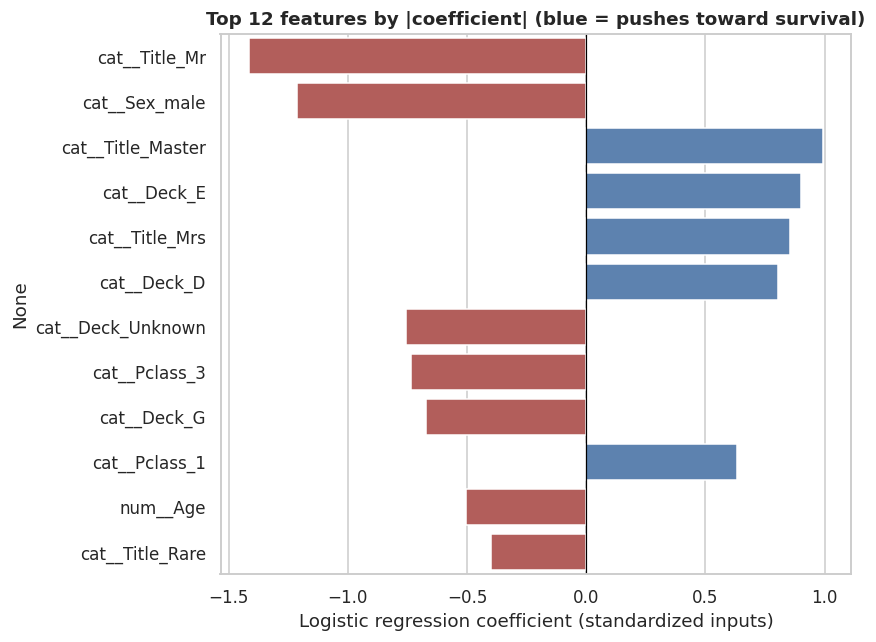

In [9]:
feat_names = logreg.named_steps["pre"].get_feature_names_out()
coefs = logreg.named_steps["clf"].coef_[0]
importance = pd.Series(coefs, index=feat_names).sort_values(key=np.abs, ascending=False)

plt.figure(figsize=(8, 6))
top = importance.head(12)
colors = ["#4f81bd" if v > 0 else "#c0504d" for v in top.values]
sns.barplot(x=top.values, y=top.index, palette=colors, hue=top.index, legend=False)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 12 features by |coefficient| (blue = pushes toward survival)")
plt.xlabel("Logistic regression coefficient (standardized inputs)")
save("10_feature_importance")

**Reading this:** `Title_Mr` and `Sex_male` are the two strongest negative predictors, and they are largely redundant with each other (nearly every `Mr` is male) — a multicollinearity issue discussed below. `Pclass_3` and `Deck_Unknown` (no cabin recorded, itself a class proxy) also push toward not surviving, while `Title_Mrs`, `Title_Master`, and higher-class decks (D, E) push toward survival. This lines up with the Task 2 EDA insights.

## 8. Limitations

**1. Redundant / collinear features.** `Sex` and `Title` (Mr/Mrs/Miss/Master) encode almost the same information — both appear among the top coefficients. This doesn't hurt this model's accuracy much, but it makes individual coefficients less trustworthy for causal interpretation, and could destabilize a more sensitive model.

**2. Rare categories create unstable estimates.** `Deck` has categories with very few passengers (`G`: 4, `T`: 1), and the test set contained deck values not seen in training (triggering an "unknown category" handling path). Any coefficient or split learned on 1–4 examples is not reliable.

**3. Small dataset, single historical event.** 891 rows is small by modern ML standards, and cross-validation shows real variance across folds (recall ranged from about 0.69 to 0.81 across 5 folds). A model this size will not generalize to other ships, eras, or emergency scenarios — the patterns are specific to the Titanic's passengers, crew procedures, and lifeboat allocation that night.

**4. The imputed `Age` values are synthetic.** About 20% of `Age` values were filled in Task 1 using group medians, not observed data. The model treats them identically to real ages, slightly understating true uncertainty for those rows.

**5. No hyperparameter tuning or feature selection.** This is intentionally a baseline: default `LogisticRegression` settings, no L1/L2 regularization search, no feature selection. A tuned model or a tree-based method (Random Forest, Gradient Boosting) would likely score somewhat higher, especially on the non-linear family-size effect found in Task 2.

**6. Precision/recall trade-off is unexamined.** The default 0.5 probability threshold was used. Recall on `Survived` (~0.78) is lower than precision (~0.82); if the real-world cost of missing a survivor were higher than the cost of a false alarm, the threshold should be tuned, which we have not done here.

**7. Fairness / proxy-variable concern.** `Sex`, `Pclass`, and `Deck` (a class proxy) are the model's strongest predictors. If a model like this ever informed a real decision about who receives help, that would encode the same historical inequities present in the data ("women and children first", and unequal access to lifeboats by class) rather than any general truth. This model is appropriate only as a historical/educational exercise, not as a template for real triage decisions.

**8. Single random seed.** All splits use `random_state=42`. Results would shift somewhat under a different seed; cross-validation (Section 6) partially addresses this but doesn't eliminate it.

### Summary
| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Naive (majority class) | ~0.62 | — | 0.00 | — | 0.50 |
| Logistic Regression (test split) | ~0.85 | ~0.82 | ~0.78 | ~0.80 | ~0.87 |
| Logistic Regression (5-fold CV mean) | ~0.84 | ~0.80 | ~0.77 | ~0.78 | ~0.87 |

The baseline clears the naive floor by a wide margin and is reasonably stable across folds, but points 1–7 above should be addressed before treating it as more than a first pass.
